## Acidentes de Trânsito nas Rodovias Federais Brasileiras
**Nome:** Leonardo Quederoli Leme - **RA:** 241020409<br>
**Nome:** Luís Fernando das Chagas - **RA:** 241020034

## Contexto do problema
A malha viária federal estende-se por dezenas de milhares de quilômetros, abrangendo realidades geográficas, climáticas e de tráfego profundamente heterogêneas. O enfrentamento da violência no trânsito por parte dos órgãos fiscalizadores enfrenta um gargalo estrutural: a assimetria entre a extensão territorial a ser coberta e a limitação dos recursos operacionais disponíveis, que incluem contingente de agentes, viaturas, radares móveis e etilômetros.

A distribuição tradicional da fiscalização por vezes baseou-se em percepções empíricas ou no patrulhamento ostensivo genérico, modelos que demonstram limitação para conter sinistros em janelas específicas de vulnerabilidade. A consolidação do repositório DATATRAN/PRF possibilita uma transição metodológica para a Segurança Viária Baseada em Evidências (Data-Driven Policing). Por meio da exploração sistemática desses dados e de técnicas de segmentação, torna-se viável transformar dados históricos em inteligência tática, fundamentando a tomada de decisão sobre onde e quando intervir.       


## Problema central
O problema central investigado nesta análise é a distribuição não uniforme da severidade dos acidentes ao longo da malha rodoviária. As ocorrências que resultam em lesões graves ou fatalidades não ocorrem ao acaso; elas tendem a se adensar na interseção de fatores contextuais específicos. Elementos como a transição de iluminação natural (crepúsculo e madrugada), a configuração da via (pista simples e traçados em curva), a ocorrência de intempéries (chuva e neblina) e condutas humanas de risco atuam de forma sinérgica, multiplicando a energia dos impactos.

O propósito deste relatório analítico é decompor os sinistros em suas variáveis explicativas, fornecendo ao órgão de trânsito matrizes claras de priorização para otimizar escalas de serviço, posicionamento de equipamentos e operações ostensivas focadas na mitigação de mortes.

## Limpeza e Preparação dos Dados

Foram selecionados dois datasets com informações conjuntas a respeito de dados de sinistros de trânsito, registrados pela Polícia Rodoviária Federal ao longo do ano de 2025. Um dos datasets apresenta o registro de sinistros agrupados por ocorrência, ou seja, possui um registro para cada sinistro com ocorrência nas rodovias federais do Brasil. O segundo dataset apresenta o registro de sinistros agrupados por pessoa, de modo que mais de um registro possa tratar do mesmo sinistro, dependendo da quantidade de veículos e pessoas envolvidas na ocorrência. Para uma análise abrangente dos dados, as informações de ambos os datasets serão utilizados, visto que os dados de cada registro de sinistro agrupado por pessoa está relacionado a um dos sinistros agrupados por ocorrência através de um ID.

In [29]:
# Importação das bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
import numpy as np
import plotly.express as px
import squarify


# Configura como os dataframes serão exibidos
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

# Carrega os dois datasets que serão utilizados
df1 = pd.read_csv('datatran2025.csv', sep=';', encoding='ISO-8859-1') # Sinistros agrupados por ocorrência
df2 = pd.read_csv('acidentes2025.csv', sep=';', encoding='ISO-8859-1') # Sinistros agrupados por pessoa

### Preencher Dados Faltantes e Corrigir Inconsistências

In [30]:
# Somatório do total de rows NaN em cada coluna
df1.isna().sum()[df1.isna().sum() > 0]

classificacao_acidente     1
regional                   2
delegacia                 22
uop                       38
dtype: int64

In [31]:
# Somatório do total de rows NaN em cada coluna
df2.isna().sum()[df2.isna().sum() > 0]

classificacao_acidente        7
tipo_veiculo               6341
tipo_envolvido            17150
estado_fisico             17150
sexo                      17150
regional                      6
delegacia                    74
uop                         130
dtype: int64

Buscou-se corrigir inconsistências encontradas nos datasets preenchendo os campos com dados faltantes, corrigindo os valores de variáveis derivadas e alterando o nome de algumas colunas para torná-los corretos ou mais compreensíveis. Primeiramente, todos os campos com dados faltantes de variáveis categóricas foram preenchidos com "Não Informado", termo já utilizado no dataset para identificar situações onde não há ciência sobre uma determinada informação do registro.

In [32]:
# Preenche as rows com conteúdo NaN das colunas específicadas, com o termo "Não Informado"
df1[["regional", "delegacia", "uop"]] = df1[["regional", "delegacia", "uop"]].fillna("Não Informado")
df2[["regional", "delegacia", "uop", "tipo_veiculo", "tipo_envolvido", "estado_fisico", "sexo"]] = df2[["regional", "delegacia", "uop", "tipo_veiculo", "tipo_envolvido", "estado_fisico", "sexo"]].fillna("Não Informado")

Para preencher os campos faltantes da coluna "classificacao_acidente" redefiniu-se o valor de todos os elementos da coluna, garantindo que todos obedecessem a mesma lógica e estivessem classificados corretamente. Isso foi feito levando em consideração a quantidade de indivíduos envolvidos e seus estados físicos após o acidente. Sendo o número de mortos acima de 0, o acidente é classificado como "Com Vítimas Fatais". Se não houver nenhuma fatalidade mas houver pelo menos um indivíduo ferido, o acidente passa a ser classificado como "Com Vítimas Feridas". Por fim, caso o acidente não se encaixe em nenhuma das classificações anteriores ele é considerado "Sem Vítimas". Após preencher a coluna no primeiro dataset, seus valores são copiados para as colunas do segundo dataset que correspodem ao mesmo ID da ocorrência.

In [33]:
# Determina um conjunto de condições
conditions = [
    (df1["mortos"] > 0),
    (df1["feridos"] > 0),
]

# Determina um conjunto de escolhas
choices = ["Com Vítimas Fatais", "Com Vítimas Feridas"]

# Preenche a coluna com as escolhas definidas de acordo com cada condição
# Caso nenhuma condição seja cumprida, a coluna é preenchida com o default
df1["classificacao_acidente"] = np.select(conditions, choices, default="Sem Vítimas") 

In [34]:
# Cria um mapa atribuindo a classificação do acidente ao ID da sua respectiva ocorrência
mapping = df1.set_index("id")["classificacao_acidente"]

# Preenche a coluna com os dados do mapa onde o ID da ocorrência é equivalente
df2["classificacao_acidente"] = df2["id"].map(mapping)

Foram identificadas ainda inconsistências no cálculo do número de pessoas envolvidas na ocorrência, dado registrado no primeiro dataset. Em vários dos registros a soma de pessoas feridas, mortas, ilesas e/ou não registradas não equivale ao valor presente na coluna que determina a quantidade total de pessoas. Para resolver esse problema e garantir a integridade dos dados, todos os cálculos foram refeitos.

In [35]:
# Determina a quantidade de feridos como a soma de feridos leves e graves
df1["feridos"] = df1["feridos_leves"] + df1["feridos_graves"]

# Determina o total de pessoas como a soma de óbitos, feridos, ilesos e não informados
df1["pessoas"] = df1["mortos"] + df1["ilesos"] + df1["ignorados"] + df1["feridos"]

Por fim, as seguintes colunas foram renomeadas:
- O termo "ignorados" foi alterado para "não informados", se referindo aos indivíduos cujo estado físico após o acidente é desconhecido;
- O nome da coluna "condicao_metereologica" foi devidamente corrigido para "condicao_meteorologica";
- A coluna "uso_solo" foi renomeada para "local_acidente", facilitando sua compreensão.

In [36]:
# Altera os nomes das colunas em questão
df1.rename(columns={"ignorados" : "nao_informados", "uso_solo" : "local_acidente", "condicao_metereologica" : "condicao_meteorologica"}, inplace = True)
df2.rename(columns={"uso_solo" : "local_acidente", "condicao_metereologica" : "condicao_meteorologica"}, inplace = True)

### Padronizar e Preparar Dados para Análise

A maneira com que os campos categóricos são representados varia com alguns constituindo strings com todos os caracteres em minúsculo, outros com todos os caracteres maiúsculos, e a maior parte com strings onde apenas o primeiro caractere é maiúsculo. Optou-se por padronizar a forma com que tais campos são representados, mantendo todas as strings com caracteres minúsculos.

In [37]:
# Define as colunas que terão seus campos padronizados
columns_to_lower_df1 = ["municipio", "causa_acidente", "tipo_acidente", "classificacao_acidente", "fase_dia", "sentido_via", "condicao_meteorologica", "tipo_pista", "tracado_via", "local_acidente"]
columns_to_lower_df2 = ["municipio", "causa_acidente", "tipo_acidente", "classificacao_acidente", "fase_dia", "sentido_via", "condicao_meteorologica", "tipo_pista", "tracado_via", "local_acidente", "tipo_veiculo", "tipo_envolvido", "estado_fisico", "sexo"]

# Torna minúsculo todos os caracteres das strings nas colunas especificadas 
df1[columns_to_lower_df1] = df1[columns_to_lower_df1].map(lambda x : x.lower())
df2[columns_to_lower_df2] = df2[columns_to_lower_df2].map(lambda x : x.lower())

A coluna "horario" de ambos os datasets foi formatada, convertendo o conteúdo que anteriormente era uma string para o objeto time, proveniente da biblioteca pandas.

In [38]:
# Formata a coluna "horario", convertendo string em time
df1["horario"] = pd.to_datetime(df1["horario"], format = "%H:%M:%S").dt.time
df2["horario"] = pd.to_datetime(df2["horario"], format = "%H:%M:%S").dt.time

Foram selecionadas as colunas cujos conteúdos não serão úteis no processo de análise, e as mesmas serão removidas dos datasets.

In [39]:
# Remove as colunas em questão
df1.drop(columns = ["km", "regional", "delegacia", "uop"], inplace = True)
df2.drop(columns = ["pesid", "km", "id_veiculo", "marca", "sexo", "ilesos", "feridos_leves", "feridos_graves", "mortos", "regional", "delegacia", "uop"], inplace = True)

A coluna "local_acidente" usa os termos "Sim" e "Não" para representar, respectivamente, rodovias localizadas em zonas urbanas ou rurais. A utilização desses termos é contra-intuitiva e, portanto, eles serão devidamente alterados para seus equivalentes.

In [40]:
# Altera os campos da coluna "local_acidente" seguindo as regras de tradução definidas a seguir
local = {"sim" : "urbano", "não" : "rural"}

df1["local_acidente"] = df1["local_acidente"].map(local)
df2["local_acidente"] = df2["local_acidente"].map(local)

In [41]:
df1

,id,data_inversa,dia_semana,horario,uf,br,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_meteorologica,tipo_pista,tracado_via,local_acidente,pessoas,mortos,feridos_leves,feridos_graves,ilesos,nao_informados,feridos,veiculos,latitude,longitude
0,652493,2025-01-01,quarta-feira,06:20:00,SP,116,guarulhos,reação tardia ou ineficiente do condutor,tombamento,com vítimas feridas,pleno dia,decrescente,céu claro,múltipla,reta;declive,urbano,2,0,1,0,0,1,1,2,"-23,48586772","-46,54075317"
1,652519,2025-01-01,quarta-feira,07:50:00,CE,116,penaforte,pista esburacada,colisão frontal,com vítimas fatais,pleno dia,crescente,céu claro,simples,reta,rural,7,1,1,0,1,4,1,6,"-7,812288","-39,08333306"
2,652522,2025-01-01,quarta-feira,08:45:00,PR,369,cornelio procopio,reação tardia ou ineficiente do condutor,colisão traseira,com vítimas feridas,pleno dia,crescente,sol,dupla,reta;aclive,urbano,5,0,3,0,2,0,3,2,"-23,182565","-50,637228"
3,652544,2025-01-01,quarta-feira,11:00:00,PR,116,campina grande do sul,reação tardia ou ineficiente do condutor,saída de leito carroçável,com vítimas feridas,pleno dia,crescente,céu claro,dupla,reta,rural,5,0,1,0,4,0,1,2,"-25,36517687","-49,04223028"
4,652549,2025-01-01,quarta-feira,09:30:00,MG,251,francisco sa,velocidade incompatível,colisão frontal,com vítimas feridas,pleno dia,decrescente,chuva,simples,curva;declive,rural,5,0,1,1,1,2,2,4,"-16,46801304","-43,43121303"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72524,757462,2025-12-20,sábado,13:10:00,MG,381,jaguaracu,acessar a via sem observar a presença dos outr...,colisão transversal,com vítimas feridas,pleno dia,decrescente,céu claro,simples,interseção de vias,rural,3,0,2,0,1,0,2,2,"-19,607","-42,7611"
72525,757492,2025-09-27,sábado,13:50:00,SC,282,herval doeste,conversão proibida,colisão transversal,com vítimas feridas,pleno dia,decrescente,céu claro,simples,reta;declive,rural,4,0,1,1,0,2,2,3,"-27,2096","-51,50077"
72526,757593,2025-12-14,domingo,13:50:00,PE,104,caruaru,ausência de reação do condutor,colisão transversal,com vítimas feridas,pleno dia,crescente,céu claro,dupla,reta,urbano,3,0,1,0,2,0,1,2,"-8,25368","-35,97546"
72527,758175,2025-12-15,segunda-feira,15:50:00,SC,101,camboriu,condutor deixou de manter distância do veículo...,colisão traseira,sem vítimas,pleno dia,crescente,sol,dupla,reta,urbano,2,0,0,0,2,0,0,2,"-26,99305955","-48,6609548"


In [42]:
df2

,id,data_inversa,dia_semana,horario,uf,br,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_meteorologica,tipo_pista,tracado_via,local_acidente,tipo_veiculo,ano_fabricacao_veiculo,tipo_envolvido,estado_fisico,idade,latitude,longitude
0,652493,2025-01-01,quarta-feira,06:20:00,SP,116,guarulhos,reação tardia ou ineficiente do condutor,tombamento,com vítimas feridas,pleno dia,decrescente,céu claro,múltipla,reta;declive,urbano,caminhão,0,condutor,não informado,0,"-23,48586772","-46,54075317"
1,652519,2025-01-01,quarta-feira,07:50:00,CE,116,penaforte,pista esburacada,colisão frontal,com vítimas fatais,pleno dia,crescente,céu claro,simples,reta,rural,caminhão-trator,2021,condutor,ileso,31,"-7,812288","-39,08333306"
2,652522,2025-01-01,quarta-feira,08:45:00,PR,369,cornelio procopio,reação tardia ou ineficiente do condutor,colisão traseira,com vítimas feridas,pleno dia,crescente,sol,dupla,reta;aclive,urbano,caminhão,1999,condutor,ileso,60,"-23,182565","-50,637228"
3,652544,2025-01-01,quarta-feira,11:00:00,PR,116,campina grande do sul,reação tardia ou ineficiente do condutor,saída de leito carroçável,com vítimas feridas,pleno dia,crescente,céu claro,dupla,reta,rural,caminhão,2013,condutor,ileso,40,"-25,36517687","-49,04223028"
4,652549,2025-01-01,quarta-feira,09:30:00,MG,251,francisco sa,velocidade incompatível,colisão frontal,com vítimas feridas,pleno dia,decrescente,chuva,simples,curva;declive,rural,caminhão-trator,2022,condutor,ileso,55,"-16,46801304","-43,43121303"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194624,757593,2025-12-14,domingo,13:50:00,PE,104,caruaru,ausência de reação do condutor,colisão transversal,com vítimas feridas,pleno dia,crescente,céu claro,dupla,reta,urbano,automóvel,2009,condutor,ileso,41,"-8,25368","-35,97546"
194625,758175,2025-12-15,segunda-feira,15:50:00,SC,101,camboriu,condutor deixou de manter distância do veículo...,colisão traseira,sem vítimas,pleno dia,crescente,sol,dupla,reta,urbano,automóvel,2010,condutor,ileso,64,"-26,99305955","-48,6609548"
194626,758175,2025-12-15,segunda-feira,15:50:00,SC,101,camboriu,condutor deixou de manter distância do veículo...,colisão traseira,sem vítimas,pleno dia,crescente,sol,dupla,reta,urbano,caminhonete,2023,condutor,ileso,31,"-26,99305955","-48,6609548"
194627,758186,2025-11-02,domingo,23:00:00,MG,381,belo oriente,acessar a via sem observar a presença dos outr...,colisão traseira,com vítimas feridas,plena noite,decrescente,nublado,simples,reta;interseção de vias,rural,automóvel,2011,condutor,lesões graves,47,"-19,298811","-42,371921"


## Análise Exploratória dos Dados (EDA)

### Questão 1 — Tipo de pista x Traçado da via: existe uma combinação que concentra mais vítimas fatais?

Essa análise busca determinar se existe uma combinação específica entre o tipo de pista (simples, dupla ou múltipla) e o traçado da via (reta, curva, declive etc.) que concentra uma proporção maior de acidentes com vítimas fatais. A técnica escolhida foi uma tabela de contingência cruzando as duas variáveis categóricas, com a taxa de letalidade calculada para cada célula e visualizada como heatmap. Essa técnica foi escolhida porque tanto tipo_pista quanto tracado_via são variáveis categóricas, e o problema central do relatório inclui a interação entre configuração da via e severidade — um gráfico de barras isolado para cada variável mostraria o efeito de cada fator separadamente, mas não capturaria a sinergia entre eles (por exemplo, se pista simples só é mais letal quando combinada com curva, e não em retas). O heatmap resolve isso ao expor diretamente a taxa de letalidade de cada combinação lado a lado.

**Técnica:** tabela de contingência (`groupby`) cruzando duas variáveis categóricas (`tipo_pista` e `tracado_via`), com a taxa de letalidade calculada para cada célula e visualizada como *heatmap*. Como `tracado_via` possui valores compostos (ex.: `curva; declive`), o campo é primeiro decomposto com `str.split(";")` + `explode`.

In [43]:
# Cópia do dataframe para não afetar df1
q1 = df1.copy()

# Decompõe os traçados compostos (ex: "curva;declive" -> duas linhas)
q1["tracado_via"] = q1["tracado_via"].str.split(";")
q1 = q1.explode("tracado_via")

# Normaliza espaços residuais, por segurança
q1["tipo_pista"] = q1["tipo_pista"].str.strip()
q1["tracado_via"] = q1["tracado_via"].str.strip()

# Variável binária: 1 se o acidente teve vítimas fatais, 0 caso contrário
q1["fatal"] = (q1["classificacao_acidente"] == "com vítimas fatais").astype(int)

# Calcula contagem e taxa de letalidade em um único groupby (evita reindex entre dois objetos)
resumo = q1.groupby(["tipo_pista", "tracado_via"]).agg(
    ocorrencias=("fatal", "size"), # Total de ocorrências (não necessariamente fatais)
    taxa_fatal=("fatal", "mean") # Proporção de acidentes fatais
).reset_index()

resumo["taxa_fatal"] = resumo["taxa_fatal"] * 100

# Filtra combinações com poucas ocorrências
MIN_OCORRENCIAS = 30
resumo_filtrado = resumo[resumo["ocorrencias"] >= MIN_OCORRENCIAS]

# Pivota para o formato de matriz usado no heatmap
taxa_fatal_filtrada = resumo_filtrado.pivot(index="tipo_pista", columns="tracado_via", values="taxa_fatal")

taxa_fatal_filtrada

tracado_via,aclive,curva,declive,desvio temporário,em obras,interseção de vias,ponte,reta,retorno regulamentado,rotatória,viaduto
tipo_pista,,,,,,,,,,,
dupla,5.924801,5.523480,7.081281,4.046243,3.927987,3.032345,5.806452,4.995884,3.433836,1.547988,4.460432
múltipla,7.855626,5.042017,5.927342,6.521739,6.593407,3.015873,8.571429,4.165949,2.777778,2.702703,6.198347
simples,12.021673,10.967479,12.388312,8.125000,7.547170,3.739483,13.684211,10.308381,3.057554,2.218430,2.760736


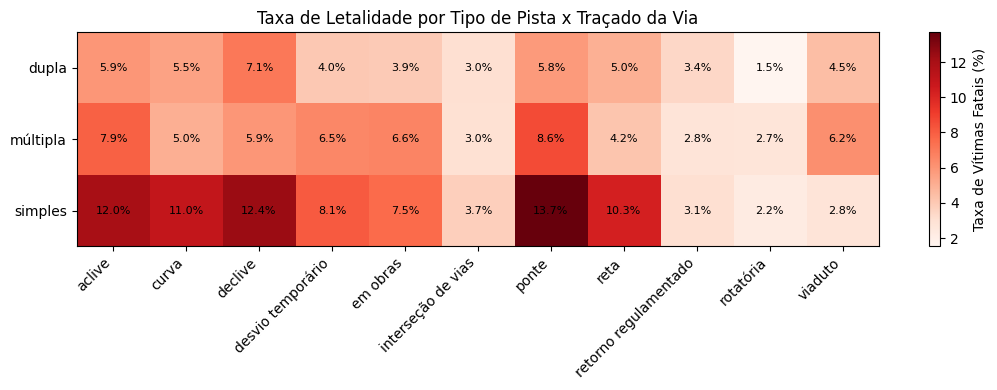

In [44]:
# Visualização 1: heatmap da taxa de letalidade por combinação

plt.figure(figsize=(11, 4))
plt.imshow(taxa_fatal_filtrada, cmap="Reds", aspect="auto")
plt.colorbar(label="Taxa de Vítimas Fatais (%)")
plt.xticks(range(len(taxa_fatal_filtrada.columns)), taxa_fatal_filtrada.columns, rotation=45, ha="right")
plt.yticks(range(len(taxa_fatal_filtrada.index)), taxa_fatal_filtrada.index)
plt.title("Taxa de Letalidade por Tipo de Pista x Traçado da Via")

# Escreve o valor numérico em cada célula do heatmap
for i in range(taxa_fatal_filtrada.shape[0]):
    for j in range(taxa_fatal_filtrada.shape[1]):
        valor = taxa_fatal_filtrada.iloc[i, j]
        if pd.notna(valor):
            plt.text(j, i, f"{valor:.1f}%", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

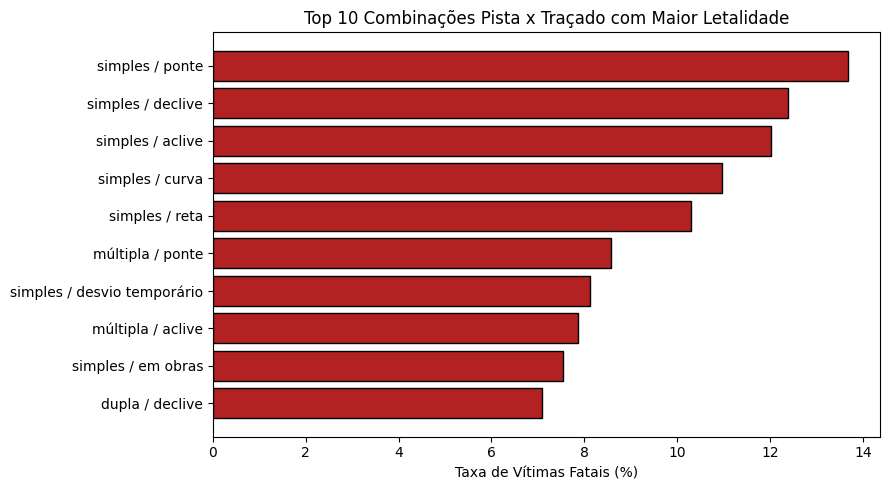

In [45]:
# Visualização 2: ranking das 10 combinações mais letais
# Ajuda a ler o heatmap acima em formato de ranking direto

top10_combinacoes = taxa_fatal_filtrada.stack().sort_values(ascending=False).head(10)
labels = [f"{pista} / {tracado}" for pista, tracado in top10_combinacoes.index]

plt.figure(figsize=(9, 5))
plt.barh(labels[::-1], top10_combinacoes.values[::-1], color="firebrick", edgecolor="black")
plt.xlabel("Taxa de Vítimas Fatais (%)")
plt.title("Top 10 Combinações Pista x Traçado com Maior Letalidade")
plt.tight_layout()
plt.show()

### Questão 2 — Horário do dia x Condição Meteorológica: a transição de luz combinada com clima adverso aumenta a letalidade?

Essa análise busca responder se os horários de transição de luz natural (amanhecer e anoitecer), quando combinados com chuva ou neblina, aumentam a taxa de letalidade dos acidentes em relação a condições de boa visibilidade. A técnica escolhida foi o temporal binning por hora do dia (extraída do campo horario) cruzada com a condição meteorológica agrupada em "boa" e "adversa", visualizada como gráfico de linha ao longo das 24 horas. Essa técnica foi escolhida porque a hora do dia é uma variável ordinal e cíclica — diferente de uma categoria fixa como fase_dia, que já vem pré-definida no dataset com poucas faixas, o agrupamento por hora permite localizar com mais precisão os picos de letalidade. O gráfico de linha, por sua vez, é mais adequado que barras para esse tipo de variável contínua/sequencial, pois deixa visível a evolução da letalidade ao longo do dia e facilita comparar visualmente se a curva da condição "adversa" se descola da curva "boa".

**Técnica:** temporal binning a partir do campo `horario` (extraindo a hora, 0–23) cruzada com a `condicao_meteorologica` agrupada em *boa* vs. *adversa*, visualizada como gráfico de linha (por ser uma variável ordinal/cíclica) e complementada por um gráfico de barras comparando diretamente as janelas de transição de luz (amanhecer/anoitecer) contra os demais horários.

In [46]:
# Cópia do dataframe para não afetar df1
q2 = df1.copy()

# Extrai a hora a partir do campo horario (já convertido para datetime.time na limpeza)
q2["hora"] = q2["horario"].apply(lambda t: t.hour)

# Agrupa a condição meteorológica em duas macro-categorias
condicoes_adversas = ["chuva", "garoa/chuvisco", "nevoeiro/neblina", "neve"]
q2["condicao_grupo"] = q2["condicao_meteorologica"].apply(
    lambda c: "adversa" if c in condicoes_adversas else "boa"
)

# Remove registros "ignorado" para não distorcer o agrupamento "boa"
q2 = q2[q2["condicao_meteorologica"] != "ignorado"]

# Variável binária de letalidade
q2["fatal"] = (q2["classificacao_acidente"] == "com vítimas fatais").astype(int)

# Taxa de letalidade (%) por hora do dia e grupo climático
letalidade_hora = q2.groupby(["hora", "condicao_grupo"])["fatal"].mean().unstack() * 100
letalidade_hora

condicao_grupo,adversa,boa
hora,,
0,9.090909,11.556982
1,9.952607,9.894332
2,12.307692,12.567714
3,10.439560,14.216634
4,9.328358,13.697546
5,8.510638,12.977099
6,6.779661,7.796102
7,2.550091,3.963111
8,3.686636,4.188008


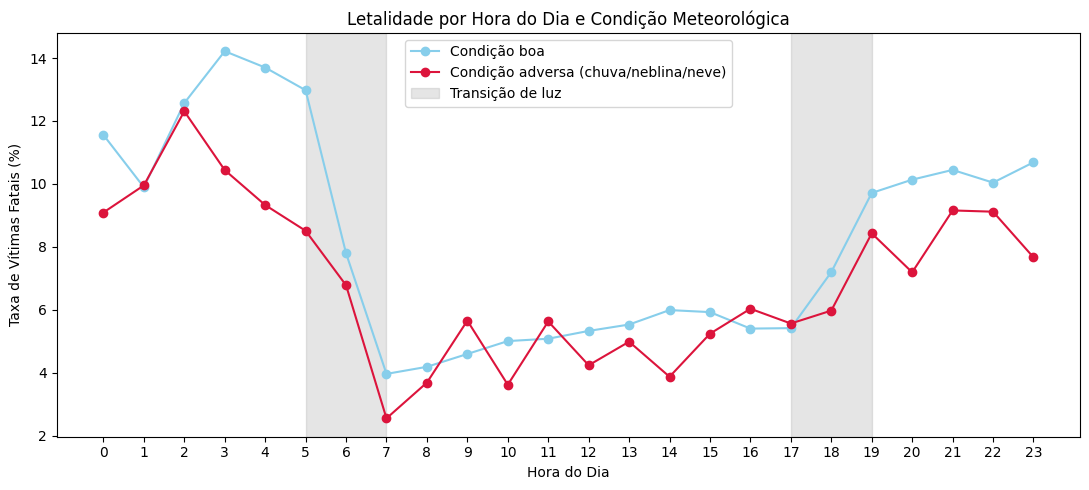

In [47]:
# Visualização 1: evolução da letalidade ao longo do dia, por condição climática

plt.figure(figsize=(11, 5))
plt.plot(letalidade_hora.index, letalidade_hora["boa"], marker="o", color="skyblue", label="Condição boa")
plt.plot(letalidade_hora.index, letalidade_hora["adversa"], marker="o", color="crimson", label="Condição adversa (chuva/neblina/neve)")

# Destaca as janelas de transição de luz natural (amanhecer e anoitecer)
plt.axvspan(5, 7, color="gray", alpha=0.2, label="Transição de luz")
plt.axvspan(17, 19, color="gray", alpha=0.2)

plt.xlabel("Hora do Dia")
plt.ylabel("Taxa de Vítimas Fatais (%)")
plt.title("Letalidade por Hora do Dia e Condição Meteorológica")
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()

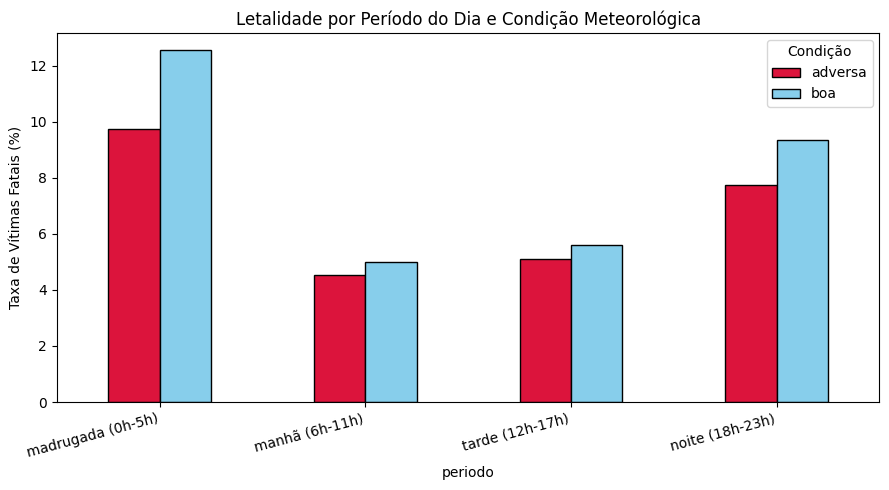

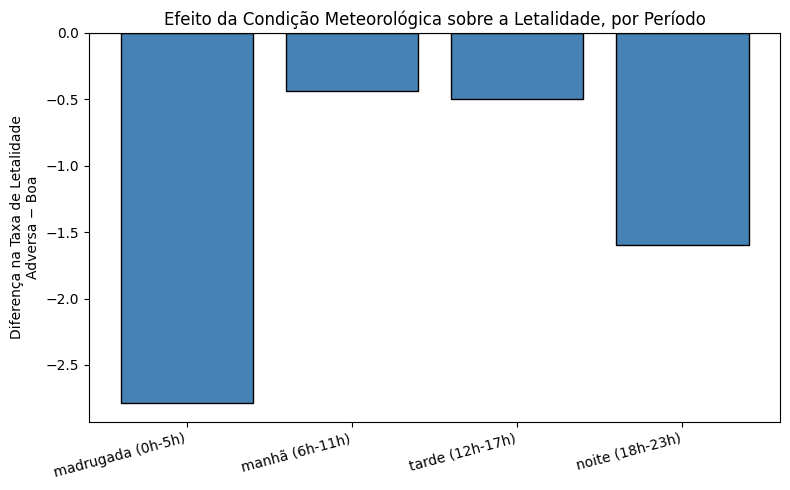

In [48]:
# Períodos definidos a partir do padrão observado na Visualização 1,
# não mais como "transição de luz" fixa, já que o pico real ocorre à noite/madrugada
def classifica_periodo(hora):
    if 0 <= hora <= 5:
        return "madrugada (0h-5h)"
    elif 6 <= hora <= 11:
        return "manhã (6h-11h)"
    elif 12 <= hora <= 17:
        return "tarde (12h-17h)"
    else:
        return "noite (18h-23h)"

q2["periodo"] = q2["hora"].apply(classifica_periodo)

ordem_periodos = ["madrugada (0h-5h)", "manhã (6h-11h)", "tarde (12h-17h)", "noite (18h-23h)"]

resumo_periodo = (
    q2.groupby(["periodo", "condicao_grupo"])["fatal"]
    .mean()
    .unstack() * 100
).reindex(ordem_periodos)

# Visualização 2a: letalidade média por período, separada por condição climática
plt.figure(figsize=(9, 5))
resumo_periodo.plot(kind="bar", color=["crimson", "skyblue"], edgecolor="black", ax=plt.gca())
plt.ylabel("Taxa de Vítimas Fatais (%)")
plt.title("Letalidade por Período do Dia e Condição Meteorológica")
plt.xticks(rotation=15, ha="right")
plt.legend(title="Condição")
plt.tight_layout()
plt.show()

# Visualização 2b: diferença (adversa - boa) por período
# Mostra diretamente se o clima adverso piora a letalidade, e em qual período isso é mais forte
diferenca = (resumo_periodo["adversa"] - resumo_periodo["boa"]).reindex(ordem_periodos)

plt.figure(figsize=(8, 5))
cores = ["firebrick" if v > 0 else "steelblue" for v in diferenca]
plt.bar(diferenca.index, diferenca.values, color=cores, edgecolor="black")
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Diferença na Taxa de Letalidade\nAdversa − Boa")
plt.title("Efeito da Condição Meteorológica sobre a Letalidade, por Período")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

### Questão 3 - Causas Presumidas por Volume e Taxa de Letalidade: quais condutas e fatores oferecem o maior risco à vida?
Essa análise investiga a relação entre o volume de sinistros provocados por cada causa presumida e a sua respetiva taxa de gravidade e letalidade. A técnica escolhida foi a visualização por Treemap hierárquico, onde a área de cada bloco representa a quantidade total de ocorrências (frequência) e a escala de cor (colormap) reflete a taxa de letalidade em porcentagem (severidade). Essa abordagem foi selecionada pois permite avaliar simultaneamente a massa crítica de acidentes e o risco real à vida em um único plano visual. Um gráfico de barras tradicional revelaria apenas o volume ou a taxa isoladamente; o treemap expõe rapidamente os "quadrantes silenciosos" de alto risco — causas com menor volume de ocorrências, porém representadas com cores intensas devido à altíssima mortalidade.

**Técnica**: Agrupamento (groupby) pela variável categórica causa_acidente no dataset df1, calculando o volume de sinistros (size) e a taxa de letalidade (mean da variável binária de mortes $\times 100$). Filtra-se um limiar estatístico de ocorrências ($N \ge 100$) para evitar distorções em causas raras. A representação gráfica é construída via Treemap bidimensional (área = volume, cor = % de letalidade).

In [49]:
# Cópia do dataframe para não afetar df1
q3 = df1.copy()

# Normalização de strings no campo de causa
q3["causa_acidente"] = q3["causa_acidente"].str.strip().str.lower()

# Remoção de registros não informados/ignorados
q3 = q3[~q3["causa_acidente"].isin(["não informado", "ignorado", "outras"])]

# Variável binária: 1 se o acidente teve vítimas fatais, 0 caso contrário
q3["fatal"] = (q3["classificacao_acidente"] == "com vítimas fatais").astype(int)

# Agrupamento e cálculo de métricas por causa
resumo_causas = q3.groupby("causa_acidente").agg(
    ocorrencias=("fatal", "size"),
    obitos_totais=("mortos", "sum"),
    taxa_letalidade=("fatal", "mean")
).reset_index()

# Conversão da taxa de letalidade para percentual
resumo_causas["taxa_letalidade"] = resumo_causas["taxa_letalidade"] * 100

# Filtro de relevância estatística (mínimo de 100 acidentes registrados)
MIN_OCORRENCIAS = 100
causas_filtradas = resumo_causas[resumo_causas["ocorrencias"] >= MIN_OCORRENCIAS].copy()

# Ordenação para inspeção inicial
causas_filtradas.sort_values(by="taxa_letalidade", ascending=False).head(10)

,causa_acidente,ocorrencias,obitos_totais,taxa_letalidade
60,suicídio (presumido),190,111,55.789474
45,pedestre andava na pista,606,252,41.254125
27,entrada inopinada do pedestre,667,209,30.434783
63,transitar na contramão,2475,961,29.737374
46,pedestre cruzava a pista fora da faixa,525,133,24.761905
44,pedestre - ingestão de álcool/ substâncias psi...,150,28,18.000000
66,ultrapassagem indevida,1770,404,17.062147
35,iluminação deficiente,157,24,14.649682
20,deficiência do sistema de iluminação/sinalização,165,24,14.545455
38,mal súbito do condutor,546,87,13.369963


In [ ]:
# Visualização: Treemap Interativo com Plotly Express
import plotly.express as px

fig = px.treemap(
    causas_filtradas,
    path=['causa_acidente'],
    values='ocorrencias',
    color='taxa_letalidade',
    color_continuous_scale='Reds',
    title='Treemap: Volume de Ocorrências (Área) vs. Taxa de Letalidade % (Cor) por Causa Presumida',
    labels={
        'ocorrencias': 'Total de Sinistros',
        'taxa_letalidade': 'Taxa de Letalidade (%)',
        'causa_acidente': 'Causa Presumida'
    }
)

fig.update_traces(
    textinfo="label+value+percent parent",
    hovertemplate="<b>%{label}</b><br>Ocorrências: %{value}<br>Taxa de Letalidade: %{color:.2f}%"
)

fig.update_layout(margin=dict(t=50, l=10, r=10, b=10))
fig.show()

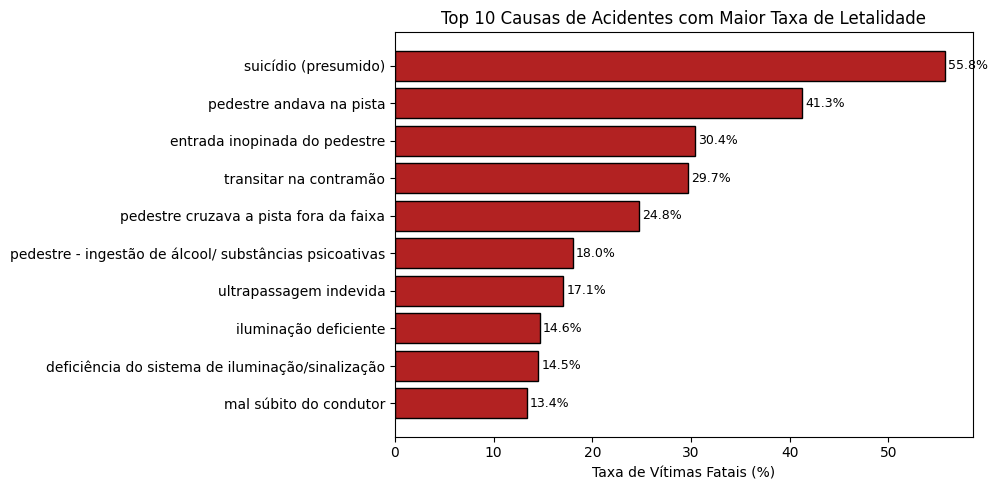

In [56]:
# Visualização 2: Ranking Top 10 Causas com Maior Taxa de Letalidade

top10_letais = causas_filtradas.sort_values(by="taxa_letalidade", ascending=False).head(10)

plt.figure(figsize=(10, 5))
bars = plt.barh(top10_letais["causa_acidente"][::-1], top10_letais["taxa_letalidade"][::-1], color="firebrick", edgecolor="black")
plt.xlabel("Taxa de Vítimas Fatais (%)")
plt.title("Top 10 Causas de Acidentes com Maior Taxa de Letalidade")

# Anotação numérica em cada barra
for index, value in enumerate(top10_letais["taxa_letalidade"][::-1]):
    plt.text(value + 0.3, index, f"{value:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()